# Netflix Movie Data Analysis Project

In [1]:
# Netflix is known for its work in data science, AI, and ML, particularly for building strong recommendation models
# and algorithms that understand customer behavior and patterns. Suppose you are working in a data-driven job role, and 
# you have a dataset of more than 9,000 movies. You need to solve the following questions to help company make informed
# business decisions accordingly.

# 1) What is the most frequent genre of movies released on Netflix?
# 2) Which has highest votes in vote avg coloumn?
# 3) What movie got the highest popularity? what's its genre?
# 4) What movie got the lowest popularity? What's its gente?
# 5) Which year has the most filmmed movies? 


# Step 1.) Importing all the neccessary libiraies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creating dataframe

In [3]:
dataframe = pd.read_csv("mymoviedb.csv", lineterminator = '\n')

In [4]:
dataframe.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


# Step 3: Data Understanding 

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [6]:
df = dataframe

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [9]:
df.describe(include = "object")

,Release_Date,Title,Overview,Original_Language,Genre,Poster_Url
count,9827,9827,9827,9827,9827,9827
unique,5893,9513,9822,43,2337,9827
top,2022-03-10,Beauty and the Beast,Wilbur the pig is scared of the end of the sea...,en,Drama,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
freq,16,4,2,7570,466,1


In [ ]:
# Exploration Summary 

- We have a dataframe consisting of 9827 rows. and 9 columns.
- Our dataset look clear, there is no duplicate and null value in database.
- Release_Date column needs to be casted into data time and to extract only the year value.
- Original_Language and Poster-Url wouldn't be so useful during analysis, so we'll drop them
- Genre column has comma seperated values and white spaces that needs to be handled and casted into category. 

# Step 4) Data Preprocessing

In [9]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'])

0      2021-12-15
1      2022-03-01
2      2022-02-25
3      2021-11-24
4      2021-12-22
          ...    
9822   1973-10-15
9823   2020-10-01
9824   2016-05-06
9825   2021-03-31
9826   1984-09-23
Name: Release_Date, Length: 9827, dtype: datetime64[ns]


In [10]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date']

0       2021
1       2022
2       2022
3       2021
4       2021
        ... 
9822    1973
9823    2020
9824    2016
9825    2021
9826    1984
Name: Release_Date, Length: 9827, dtype: int32

Droping the columns

In [11]:
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [12]:
df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

Categorize Vote_Average column

we would cut the Vote_Average values and make 4 categories popular, average, below_average, not_popular tp describe it more using categorize() function provided above


In [13]:
def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]

    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df
    

In [14]:
labels = ['not_popular', 'below_avg', 'average', 'popular']

categorize_col(df, 'Vote_Average', labels)

df['Vote_Average'].unique()

['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [15]:
df.head(3)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller


In [16]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

In [17]:
df.isna().sum()

Release_Date      0
Title             0
Popularity        0
Vote_Count        0
Vote_Average    100
Genre             0
dtype: int64

In [18]:
df.dropna(inplace = True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

# We'd Split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [19]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop = True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


#  What is the most frequent genre of movies released on Netflix?

Mathematical calculation

In [20]:
max_genre = df['Genre'].value_counts()
print('Genre: ', max_genre.idxmax())
print('count: ', max_genre.max())

Genre:  Drama
count:  3715


In [21]:
print(max_genre)

Genre
Drama              3715
Comedy             3006
Action             2652
Thriller           2473
Adventure          1829
Romance            1461
Horror             1457
Animation          1426
Family             1405
Fantasy            1295
Science Fiction    1255
Crime              1235
Mystery             765
History             426
War                 307
Music               291
TV Movie            214
Documentary         203
Western             137
Name: count, dtype: int64


visualization 

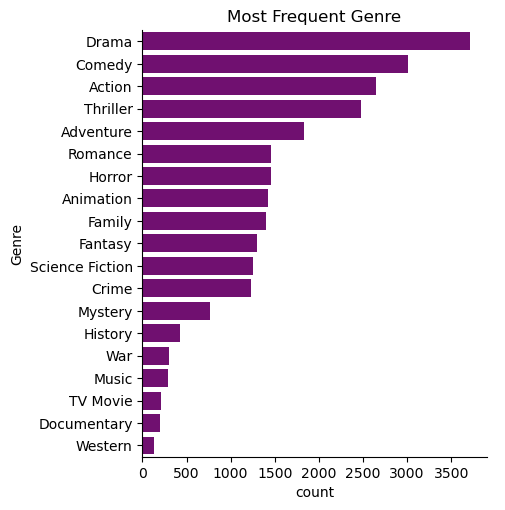

In [22]:
sns.catplot(y = 'Genre', data = df, kind = 'count',
            order = df['Genre'].value_counts().index,
            color = "purple")
plt.title('Most Frequent Genre')
plt.show()

Conclusion: "Drama" is the most frequent genre of movies released on Netflix with count of 3715.

#  Which has highest votes in vote avg coloumn?

In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


Visulaziation

Vote_Average
average        6613
popular        6520
below_avg      6348
not_popular    6071
Name: count, dtype: int64


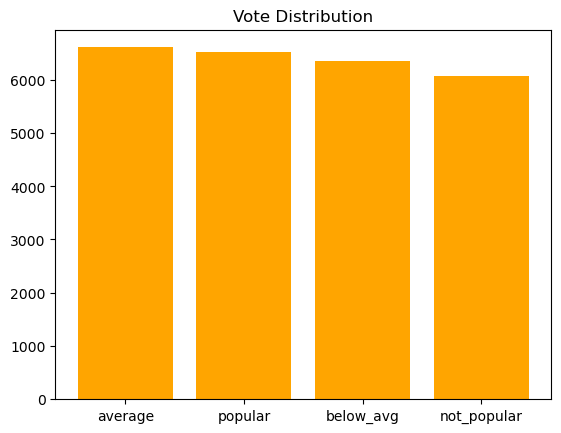

In [25]:
vote_count = df['Vote_Average'].value_counts()
print(vote_count)

plt.bar(x = vote_count.index, height = vote_count.values, color = "Orange")
plt.title("Vote Distribution")
plt.show()

# What movie got the highest Popularity? what's its genre?

 Mathematical Calculation

In [35]:
Highest_pop = df['Popularity'].max()
print("Highest Popularity:" ,Highest_pop)

Highest Popularity: 5083.954


In [38]:
Highest_movie = df[df['Popularity'] == Highest_pop]
print(Highest_movie[['Title', 'Popularity', 'Genre']])

                     Title  Popularity            Genre
0  Spider-Man: No Way Home    5083.954           Action
1  Spider-Man: No Way Home    5083.954        Adventure
2  Spider-Man: No Way Home    5083.954  Science Fiction


# What movie got the lowest popularity? What's its gente?

In [47]:
Lowest_Popularity = df['Popularity'].min()
Lowest_movie = df[df['Popularity'] == Lowest_Popularity]
print(Lowest_movie[['Title', 'Popularity', 'Genre']])

                                      Title  Popularity            Genre
25546  The United States vs. Billie Holiday      13.354            Music
25547  The United States vs. Billie Holiday      13.354            Drama
25548  The United States vs. Billie Holiday      13.354          History
25549                               Threads      13.354              War
25550                               Threads      13.354            Drama
25551                               Threads      13.354  Science Fiction


# Which year has the most filmmed movies? 

In [48]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


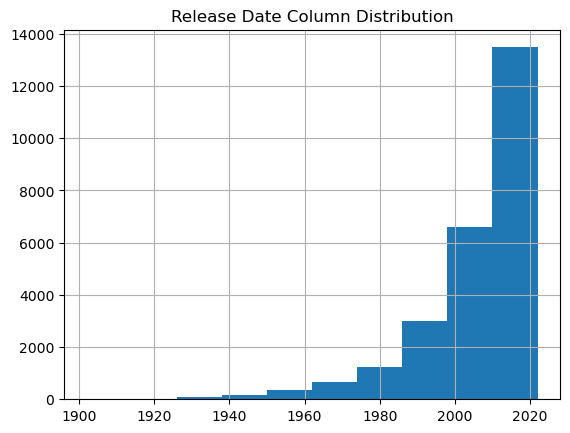

In [50]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()